### Загрузка библиотек и датасетов

In [194]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Tuple, Dict
from scipy import stats
import statsmodels.api as sm

In [195]:
orders_df = 'grocery_delivery_orders_2025_11_2026_04.csv'
MARKETING = 'grocery_delivery_marketing_communications_2025_11_2026_04-66846c55-da59-4209-9b9d-d502f92e1db7.csv'
funnel_df = 'grocery_delivery_funnel_2025_11_2026_04-c7e6b23b-3d58-458e-a748-fa0292e891a5.csv'

orders_df = pd.read_csv(orders_df, sep=',')
marketing_df = pd.read_csv(MARKETING, sep=',')
funnel_df = pd.read_csv(funnel_df, sep=',')

### EDA

#### EDA датасета orders_df

In [196]:
orders_df.head()

,order_id,session_id,client_id,address_id,store_id,city,platform,order_created_at,order_date,delivery_slot_start,...,gross_merchandise_value,discount_type,discount_amount,delivery_fee,service_fee,paid_amount,payment_method,campaign_id,experiment_group,is_marketing_touched
0,O000000112,SESS000000651,C008041,A0011675,S031,Новосибирск,ios,2025-11-01 09:00:00,2025-11-01,2025-11-01 18:00:00,...,2620.76,none,0.0,0,39.31,2660.07,cash,NaN,no_campaign,0
1,O000000026,SESS000000148,C002410,A0002250,S067,Москва,ios,2025-11-01 09:18:00,2025-11-01,2025-11-01 11:00:00,...,4767.18,none,0.0,99,71.51,4937.69,card,NaN,no_campaign,0
2,O000000169,SESS000000872,C006795,A0006500,S011,Москва,ios,2025-11-01 09:19:11,2025-11-01,2025-11-01 19:00:00,...,3112.03,none,0.0,99,0.00,3211.03,card,NaN,no_campaign,0
3,O000000072,SESS000000433,C008460,A0010616,S057,Москва,web,2025-11-01 09:27:00,2025-11-01,2025-11-01 20:00:00,...,3380.14,none,0.0,99,50.70,3529.84,card,NaN,no_campaign,0
4,O000000008,SESS000000058,C008434,A0001936,S026,Екатеринбург,ios,2025-11-01 09:31:13,2025-11-01,2025-11-01 22:00:00,...,3501.61,fixed_amount,200.0,99,0.00,3400.61,card,NaN,no_campaign,0


##### Дубликаты в orders_df

In [197]:
print(f'Количество дублирующихся строк в orders_df: {orders_df.duplicated().sum()}')

Количество дублирующихся строк в orders_df: 0


##### Функция, совмещающая в себе информацию из pandas (info, describe, nunique), а так же считающая другие статистики

In [198]:
def scan_df(df: pd.DataFrame, features: List[str], filter_col: str = None, filter_value: any = None) -> pd.DataFrame:
    scanned = []
    if filter_col and filter_col in df.columns:
        df = df[df[filter_col] == filter_value]
    features = [f for f in features if f in df.columns]
    num_rows = len(df)
    for col in features:
        not_null = df[col].notnull().sum()
        num_unique = df[col].nunique()
        scanned.append({
            'feature': col,
            'dtype': str(df[col].dtype),
            'not_null': not_null,
            'nunique': num_unique,
            'missing_%': round((1 - not_null / num_rows) * 100, 2),
            'is_id': not_null == num_unique and not_null > 0,
            'min': df[col].min() if pd.api.types.is_numeric_dtype(df[col]) else None,
            '25%': df[col].quantile(0.25) if pd.api.types.is_numeric_dtype(df[col]) else None,
            '50%': df[col].median() if pd.api.types.is_numeric_dtype(df[col]) else None,
            '75%': df[col].quantile(0.75) if pd.api.types.is_numeric_dtype(df[col]) else None,
            'max': df[col].max() if pd.api.types.is_numeric_dtype(df[col]) else None,
            'mode': df[col].mode().iloc[0] if pd.api.types.is_object_dtype(df[col]) or pd.api.types.is_datetime64_dtype(df[col]) else None
        })
    return pd.DataFrame(scanned)

##### Сканирование orders_df
При сканировании orders_df видим, что в campaign_id отсутствует 95% значений, но в этих пропусках нет ничего плохого, так как значение ставили только, если проводилась кампания

In [199]:
scan_df(orders_df, features=orders_df.columns, filter_col='dtype', filter_value='int64')

,feature,dtype,not_null,nunique,missing_%,is_id,min,25%,50%,75%,max,mode
0,order_id,object,21884,21884,0.00,True,NaN,NaN,NaN,NaN,NaN,O000000001
1,session_id,object,21884,21884,0.00,True,NaN,NaN,NaN,NaN,NaN,SESS000000004
2,client_id,object,21884,7244,0.00,False,NaN,NaN,NaN,NaN,NaN,C004689
3,address_id,object,21884,5720,0.00,False,NaN,NaN,NaN,NaN,NaN,A0003482
4,store_id,object,21884,80,0.00,False,NaN,NaN,NaN,NaN,NaN,S067
5,city,object,21884,5,0.00,False,NaN,NaN,NaN,NaN,NaN,Москва
6,platform,object,21884,3,0.00,False,NaN,NaN,NaN,NaN,NaN,ios
7,order_created_at,object,21884,21858,0.00,False,NaN,NaN,NaN,NaN,NaN,2025-11-01 18:56:41
8,order_date,object,21884,181,0.00,False,NaN,NaN,NaN,NaN,NaN,2025-11-01
9,delivery_slot_start,object,21884,2353,0.00,False,NaN,NaN,NaN,NaN,NaN,2025-11-01 11:00:00


Преобразуем временные признаки в тип datetime, создадим новые фичи для обеспечения гранулярности

In [200]:
orders_df['order_created_at'] = pd.to_datetime(orders_df['order_created_at'])
orders_df['order_date'] = pd.to_datetime(orders_df['order_date'])
orders_df['delivery_slot_start'] = pd.to_datetime(orders_df['delivery_slot_start'])
orders_df['day'] = orders_df['order_date'].dt.date
orders_df['week'] = orders_df['order_date'].dt.to_period('W').astype(str)

scan_df(orders_df, features=orders_df.columns)

,feature,dtype,not_null,nunique,missing_%,is_id,min,25%,50%,75%,max,mode
0,order_id,object,21884,21884,0.00,True,NaN,NaN,NaN,NaN,NaN,O000000001
1,session_id,object,21884,21884,0.00,True,NaN,NaN,NaN,NaN,NaN,SESS000000004
2,client_id,object,21884,7244,0.00,False,NaN,NaN,NaN,NaN,NaN,C004689
3,address_id,object,21884,5720,0.00,False,NaN,NaN,NaN,NaN,NaN,A0003482
4,store_id,object,21884,80,0.00,False,NaN,NaN,NaN,NaN,NaN,S067
5,city,object,21884,5,0.00,False,NaN,NaN,NaN,NaN,NaN,Москва
6,platform,object,21884,3,0.00,False,NaN,NaN,NaN,NaN,NaN,ios
7,order_created_at,datetime64[ns],21884,21858,0.00,False,NaN,NaN,NaN,NaN,NaN,2025-11-01 18:56:41
8,order_date,datetime64[ns],21884,181,0.00,False,NaN,NaN,NaN,NaN,NaN,2025-11-01 00:00:00
9,delivery_slot_start,datetime64[ns],21884,2353,0.00,False,NaN,NaN,NaN,NaN,NaN,2025-11-01 11:00:00


##### Функция визуализации фичей в зависимости от их типа с возможностью сегментации по определенной фиче

In [201]:
def plot_features(
    df: pd.DataFrame,
    features: List[str],
    df_name: str = None,
    target: str = None,
    max_unique_cat: int = 50,
    bins: int = 50,
    hue: str = None
    ) -> None:
    features = [f for f in features if f in df.columns]
    if target and target in df.columns:
        features = [f for f in features if f != target]
    numeric_cols = [f for f in features if pd.api.types.is_numeric_dtype(df[f])]
    cat_cols = [f for f in features if pd.api.types.is_object_dtype(df[f])]
    datetime_cols = [f for f in features if pd.api.types.is_datetime64_dtype(df[f])]
    
    high_cat = [f for f in cat_cols if df[f].nunique() > max_unique_cat]
    low_cat = [f for f in cat_cols if df[f].nunique() <= max_unique_cat]
    
    if high_cat:
        print(f'Пропущены признаки с высоким количеством уникальных значений:\n{df[high_cat].nunique()}')
    
    to_plot = numeric_cols + low_cat + datetime_cols
    
    n = len(to_plot)
    num_cols = 3
    num_rows = (n + num_cols - 1) // num_cols
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 4*num_rows))
    axes = axes.flatten() if n > 1 else [axes]
    if df_name:
        fig.suptitle(df_name)
    for i, col in enumerate(to_plot):
        ax = axes[i]
        if col in numeric_cols:
            sns.histplot(data=df, x=col, ax=ax, bins=bins)
        elif col in datetime_cols:
            sns.histplot(data=df, x=col, ax=ax, bins=bins)
            ax.tick_params(axis='x', rotation=45)
        else:
            sns.countplot(data=df, x=col, ax=ax)
            ax.tick_params(axis='x', rotation=45)
        ax.set_title(f'Распределение {col}')
        ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

##### Важные распределения из orders_df
GMV -> нормальное распределение с тяжелым хвостом
Скидки проводят нечасто в небольшом от среднего чека объеме

Большинство покупок из -> Москва, СПБ, Казань

Наиболее популярные платформы -> мобильные устройства (iOS, Android)

По заказм стабильный поток, резкое падение в последней неделе апреля

A/B тест охватывает малую часть аудитории (5-10%)

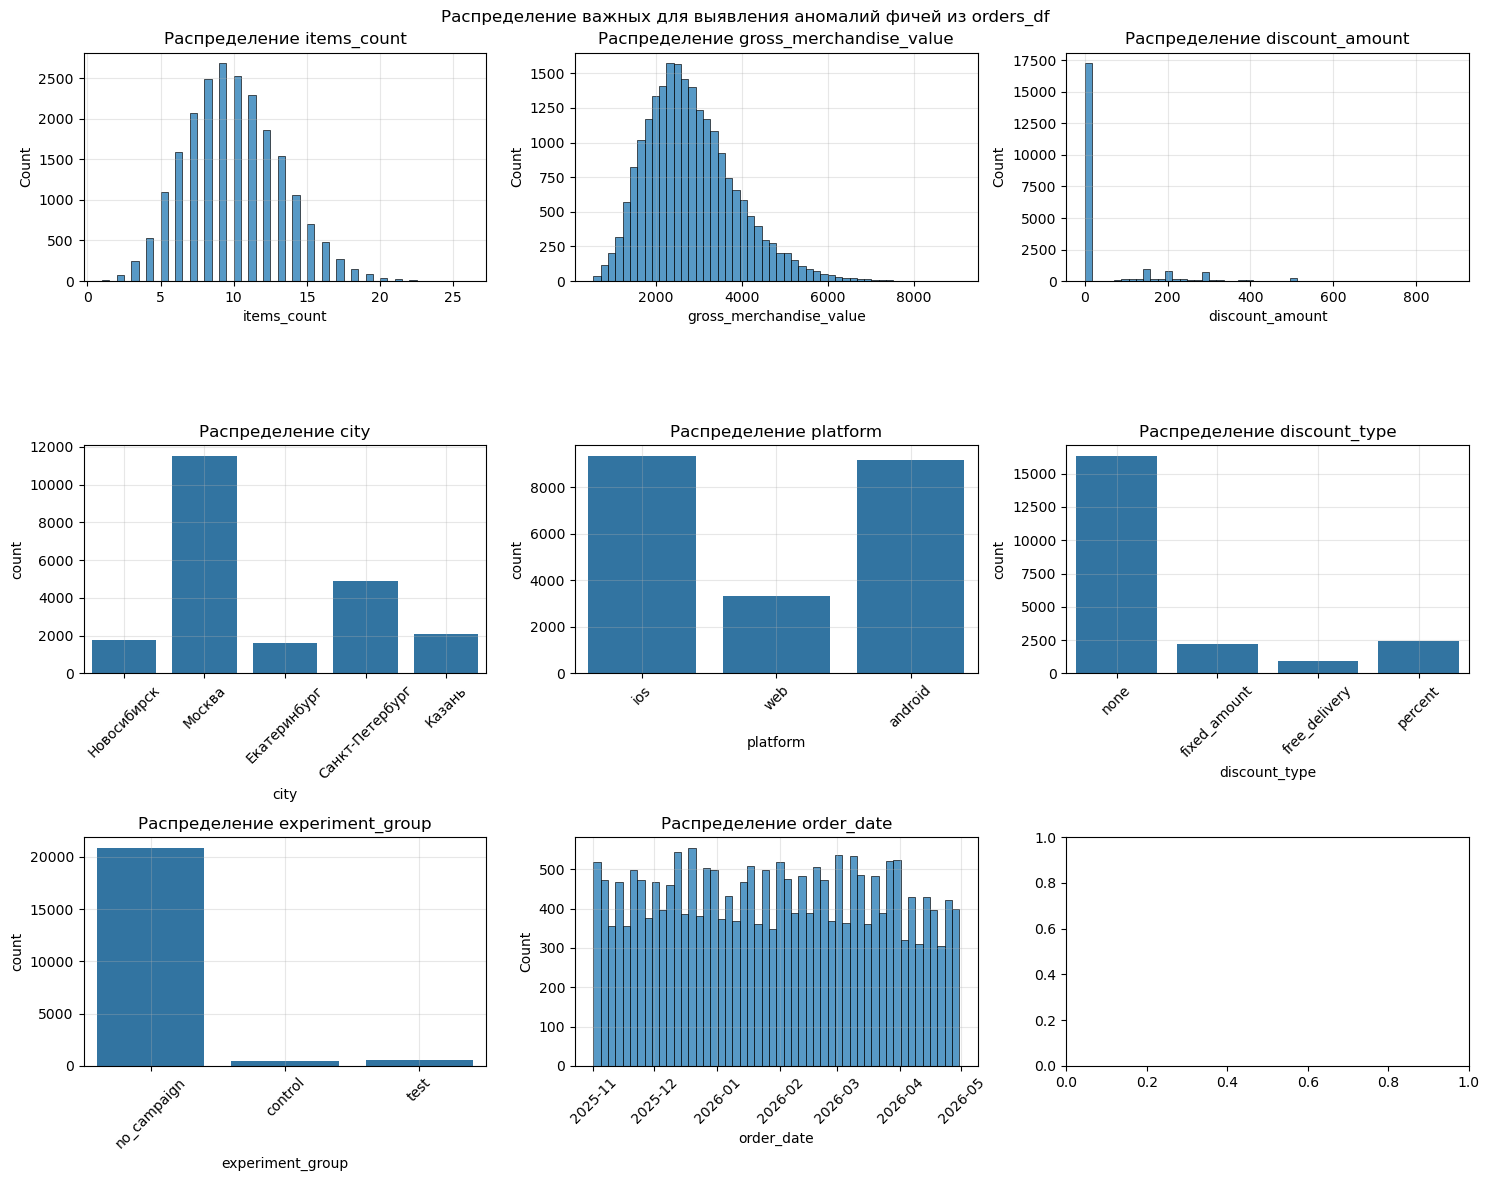

In [202]:
orders_features = ['city', 'platform', 'items_count', 'order_date', 'gross_merchandise_value', 'discount_type', 'discount_amount', 'experiment_group']
plot_features(orders_df, orders_features, 'Распределение важных для выявления аномалий фичей из orders_df')

##### Построим визуализацию основных метрик по неделям

In [203]:
orders_weekly_df = orders_df.groupby('week').agg(
    turnover=('paid_amount', 'sum'),
    gmv=('gross_merchandise_value', 'sum'),
    order_count=('order_id', 'nunique'),
    avg_check=('paid_amount', 'mean'),
    discount_amount=('discount_amount', 'sum')
).reset_index()
orders_weekly_df['discount_rate'] = orders_weekly_df['discount_amount'] / orders_weekly_df['gmv']


In [204]:
def plot_linear(df: pd.DataFrame, agg_period: str, metrics: List[Tuple[str,...]], main_title: str = None) -> None:
    num_lines = len(metrics)
    fig, axes = plt.subplots(num_lines, 1, figsize=(18, 15), sharex=True)
    if main_title:
        fig.suptitle(main_title, fontsize=14)
    for ax, (col, title) in zip(axes, metrics):
        ax.plot(df[agg_period], df[col], marker='o')
        ax.set_title(title, fontsize=14)
        ax.grid(alpha=0.3)
        ax.tick_params(axis='x', rotation=45)
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Доля скидок остается на уровне 1-2% со скачком 8 марта

С 16 марта падают основные метрики - GMV, число заказов. Средний чек же падает вместе с ними, но начинает повышаться к середине апреля

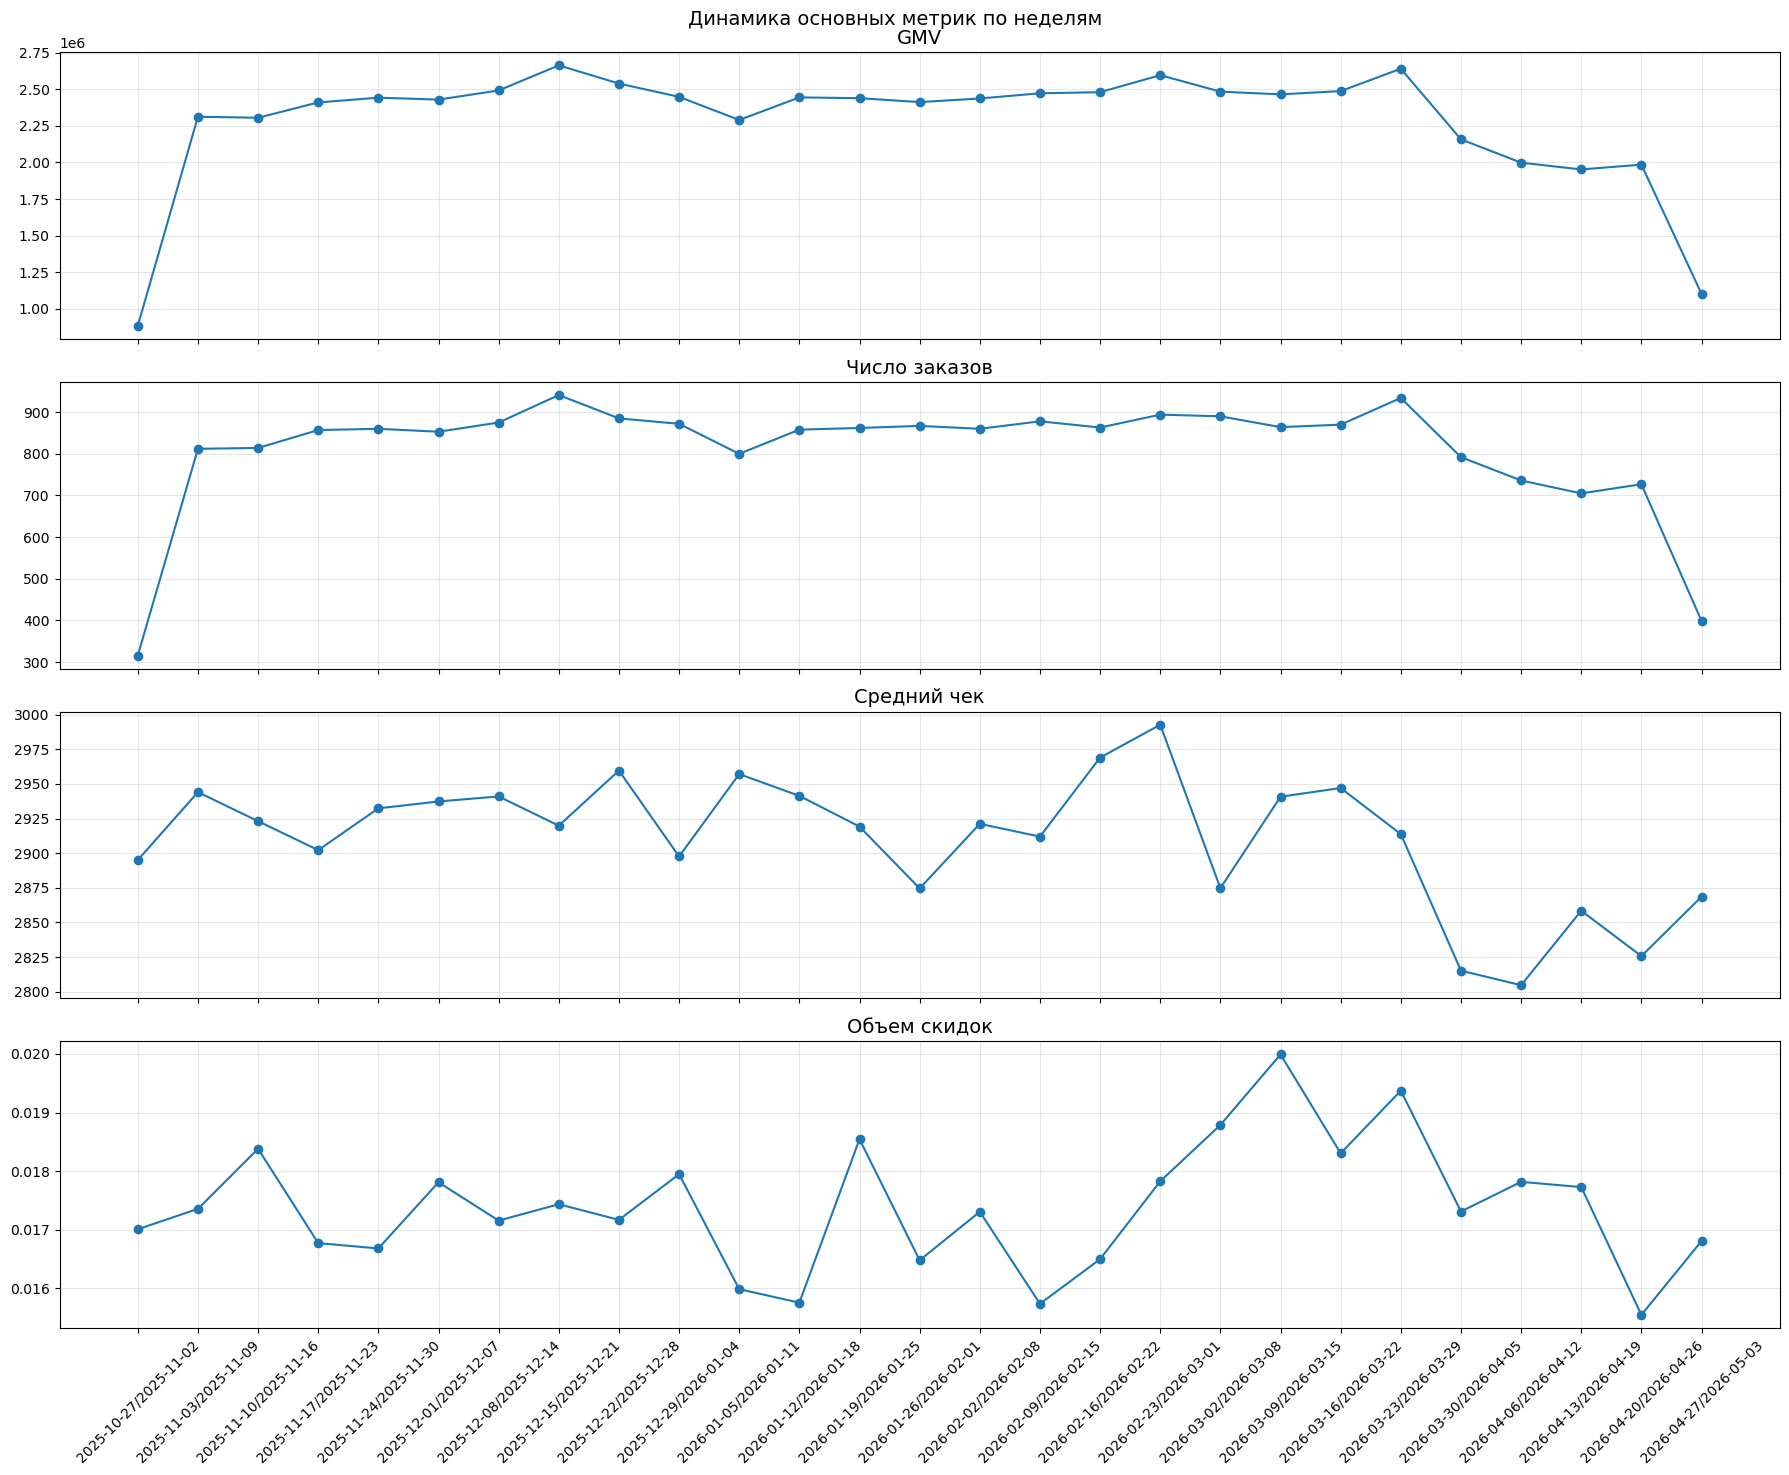

In [205]:
plot_linear(
    df=orders_weekly_df,
    agg_period='week',
    metrics=[
        ('gmv', 'GMV'),
        ('order_count', 'Число заказов'),
        ('avg_check', 'Средний чек'),
        ('discount_rate','Объем скидок')
    ],
    main_title='Динамика основных метрик по неделям'
)

#### Проведём EDA датасета marketing

In [206]:
marketing_df.head()

,communication_id,campaign_id,communication_type,client_id,send_datetime,send_date,send_hour,timing_period,experiment_group,send_status
0,COM00000001,CMP0001,email,C000437,2025-11-01 18:15:00,2025-11-01,18,evening,control,holdout_control
1,COM00000002,CMP0001,email,C004047,2025-11-01 18:15:00,2025-11-01,18,evening,control,holdout_control
2,COM00000003,CMP0001,email,C003127,2025-11-01 18:15:00,2025-11-01,18,evening,test,sent
3,COM00000004,CMP0001,email,C005987,2025-11-01 18:15:00,2025-11-01,18,evening,test,sent
4,COM00000005,CMP0001,email,C002831,2025-11-01 18:15:00,2025-11-01,18,evening,test,sent


##### Дубликаты в датасете marketing_df

In [207]:
print(f'Количество дублирующихся строк в marketing_df: {marketing_df.duplicated().sum()}')

Количество дублирующихся строк в marketing_df: 0


##### Сканирование marketing_df

In [208]:
scan_df(marketing_df, marketing_df.columns)

,feature,dtype,not_null,nunique,missing_%,is_id,min,25%,50%,75%,max,mode
0,communication_id,object,72193,72193,0.0,True,NaN,NaN,NaN,NaN,NaN,COM00000001
1,campaign_id,object,72193,61,0.0,False,NaN,NaN,NaN,NaN,NaN,CMP0010
2,communication_type,object,72193,3,0.0,False,NaN,NaN,NaN,NaN,NaN,push
3,client_id,object,72193,8499,0.0,False,NaN,NaN,NaN,NaN,NaN,C001044
4,send_datetime,object,72193,61,0.0,False,NaN,NaN,NaN,NaN,NaN,2025-11-28 20:15:00
5,send_date,object,72193,61,0.0,False,NaN,NaN,NaN,NaN,NaN,2025-11-28
6,send_hour,int64,72193,7,0.0,False,6.0,17.0,18.0,19.0,20.0,None
7,timing_period,object,72193,2,0.0,False,NaN,NaN,NaN,NaN,NaN,evening
8,experiment_group,object,72193,2,0.0,False,NaN,NaN,NaN,NaN,NaN,control
9,send_status,object,72193,2,0.0,False,NaN,NaN,NaN,NaN,NaN,holdout_control


In [209]:
marketing_df['send_datetime'] = pd.to_datetime(marketing_df['send_datetime'])
scan_df(marketing_df, marketing_df.columns)

,feature,dtype,not_null,nunique,missing_%,is_id,min,25%,50%,75%,max,mode
0,communication_id,object,72193,72193,0.0,True,NaN,NaN,NaN,NaN,NaN,COM00000001
1,campaign_id,object,72193,61,0.0,False,NaN,NaN,NaN,NaN,NaN,CMP0010
2,communication_type,object,72193,3,0.0,False,NaN,NaN,NaN,NaN,NaN,push
3,client_id,object,72193,8499,0.0,False,NaN,NaN,NaN,NaN,NaN,C001044
4,send_datetime,datetime64[ns],72193,61,0.0,False,NaN,NaN,NaN,NaN,NaN,2025-11-28 20:15:00
5,send_date,object,72193,61,0.0,False,NaN,NaN,NaN,NaN,NaN,2025-11-28
6,send_hour,int64,72193,7,0.0,False,6.0,17.0,18.0,19.0,20.0,None
7,timing_period,object,72193,2,0.0,False,NaN,NaN,NaN,NaN,NaN,evening
8,experiment_group,object,72193,2,0.0,False,NaN,NaN,NaN,NaN,NaN,control
9,send_status,object,72193,2,0.0,False,NaN,NaN,NaN,NaN,NaN,holdout_control


##### Важные распределения из marketing_df
Самым распространенным способом коммуникации стал Push

Маркетинг сервиса доставки сделан под вечерний спрос

Ровно половина пользователей получала взаимодействие

Рассылка совершалась равномерно в течение всего периода с пиками примерно раз в 1-2 недели

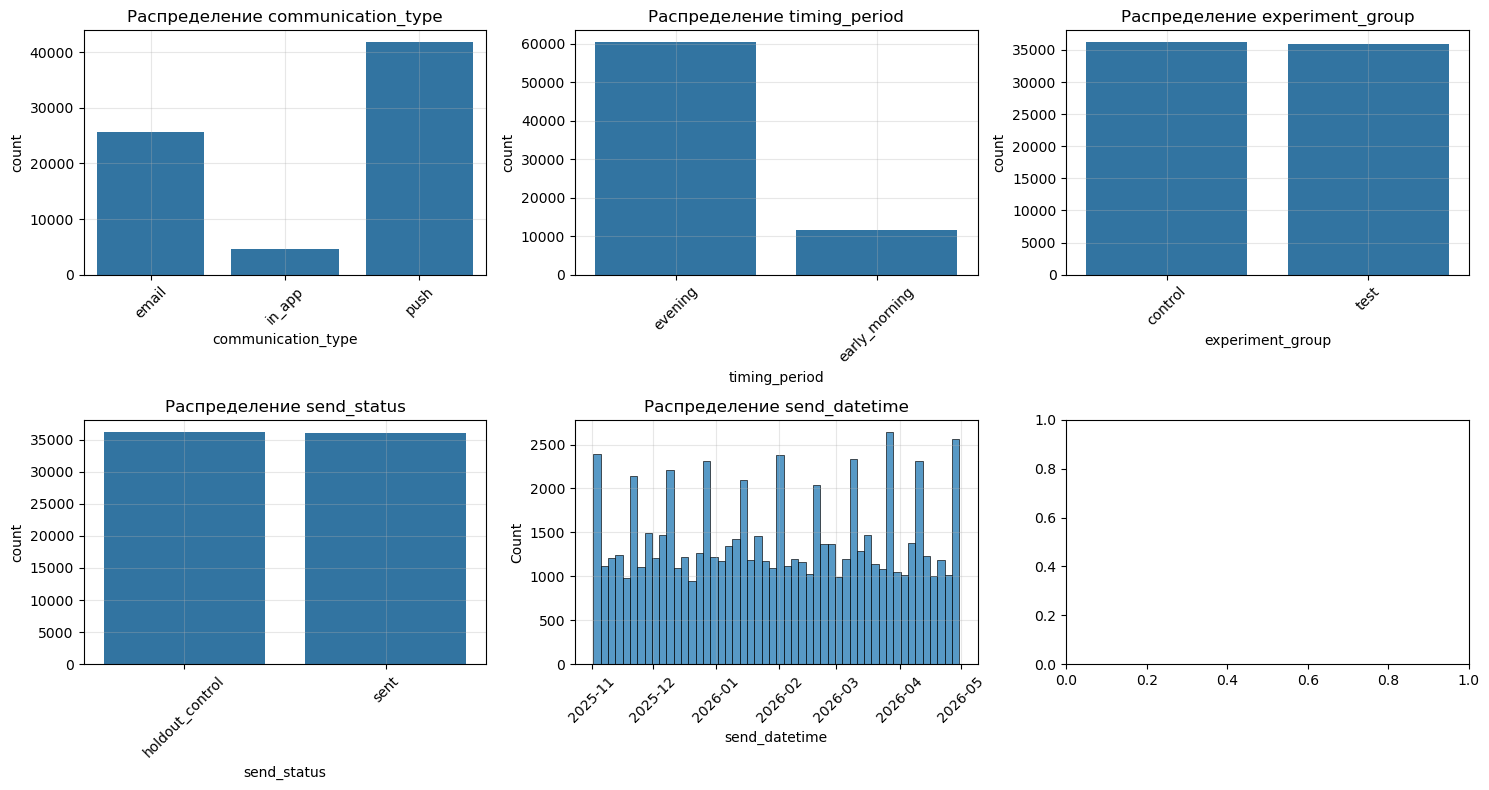

In [210]:
marketing_features = ['communication_type', 'send_datetime', 'timing_period', 'experiment_group', 'send_status']
plot_features(marketing_df, marketing_features)

##### Рассмотрим динамику коммуникация по неделям
Видим регулярные пики и спады каждые 1-2 недели, в остальном объем стабилен и в апреле 2026 ведёт себя в рамках обычных колебаний

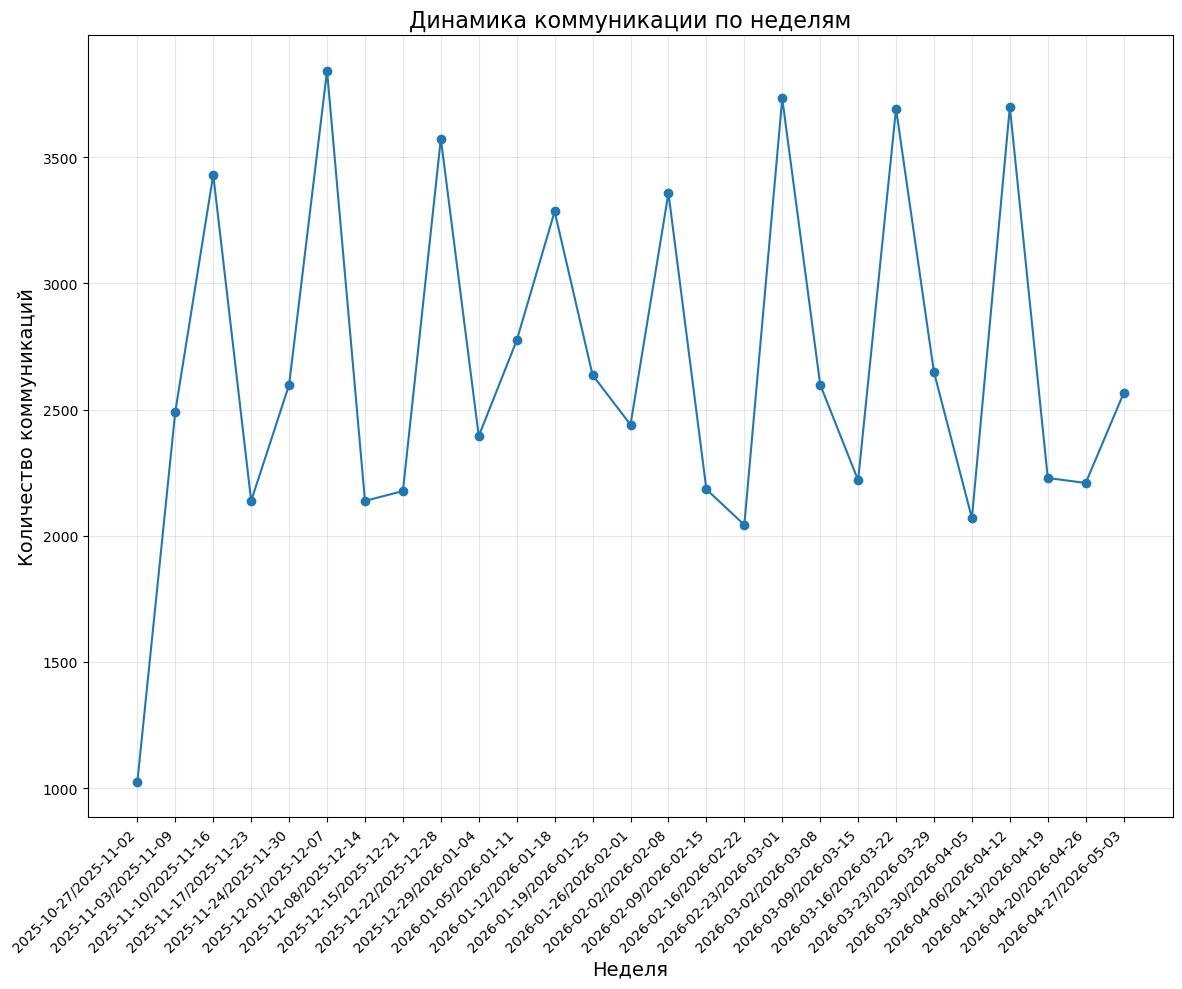

In [211]:

marketing_weekly = marketing_df.groupby(marketing_df['send_datetime'].dt.to_period('W')).size()
plt.figure(figsize=(12, 10))
plt.plot(marketing_weekly.index.astype(str), marketing_weekly.values, marker='o')
plt.title('Динамика коммуникации по неделям', fontsize=16)
plt.xlabel('Неделя', fontsize=14)
plt.ylabel('Количество коммуникаций', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Проведем EDA датасета funnel_df

In [212]:
funnel_df.head()

,session_id,client_id,address_id,session_start_at,session_date,city,platform,traffic_source,campaign_id,experiment_group,...,product_card_view,add_to_cart,cart_visit,purchase,order_id,search_at,product_card_view_at,add_to_cart_at,cart_visit_at,purchase_at
0,SESS000000514,C003975,A0000378,2025-11-01 08:04:53,2025-11-01,Москва,android,direct,NaN,no_campaign,...,1,0,0,0,NaN,2025-11-01 08:07:53,2025-11-01 08:07:53,NaN,NaN,NaN
1,SESS000000286,C000830,A0011473,2025-11-01 08:11:12,2025-11-01,Москва,android,organic,NaN,no_campaign,...,1,1,0,0,NaN,2025-11-01 08:12:12,2025-11-01 08:16:12,2025-11-01 08:23:12,NaN,NaN
2,SESS000000248,C005196,A0005849,2025-11-01 08:11:57,2025-11-01,Казань,ios,organic,NaN,no_campaign,...,1,1,1,0,NaN,2025-11-01 08:15:57,2025-11-01 08:21:57,2025-11-01 08:21:57,2025-11-01 08:31:57,NaN
3,SESS000000387,C007786,A0001717,2025-11-01 08:16:26,2025-11-01,Москва,android,direct,NaN,no_campaign,...,1,0,0,0,NaN,2025-11-01 08:18:26,2025-11-01 08:24:26,NaN,NaN,NaN
4,SESS000000197,C001541,A0001204,2025-11-01 08:21:22,2025-11-01,Санкт-Петербург,web,crm,CMP0001,test,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


##### Дубликаты в датасете funnel_df

In [213]:
print(f'Количество дублирующихся строк в funnel_df: {funnel_df.duplicated().sum()}')

Количество дублирующихся строк в funnel_df: 0


##### Сканирование funnel_df

In [214]:
scan_df(funnel_df, funnel_df.columns)

,feature,dtype,not_null,nunique,missing_%,is_id,min,25%,50%,75%,max,mode
0,session_id,object,144710,144710,0.00,True,NaN,NaN,NaN,NaN,NaN,SESS000000001
1,client_id,object,144710,8491,0.00,False,NaN,NaN,NaN,NaN,NaN,C007188
2,address_id,object,144710,6451,0.00,False,NaN,NaN,NaN,NaN,NaN,A0010504
3,session_start_at,object,144710,143614,0.00,False,NaN,NaN,NaN,NaN,NaN,2025-11-20 15:59:24
4,session_date,object,144710,181,0.00,False,NaN,NaN,NaN,NaN,NaN,2025-12-14
5,city,object,144710,5,0.00,False,NaN,NaN,NaN,NaN,NaN,Москва
6,platform,object,144710,3,0.00,False,NaN,NaN,NaN,NaN,NaN,ios
7,traffic_source,object,144710,5,0.00,False,NaN,NaN,NaN,NaN,NaN,direct
8,campaign_id,object,6699,61,95.37,False,NaN,NaN,NaN,NaN,NaN,CMP0050
9,experiment_group,object,144710,3,0.00,False,NaN,NaN,NaN,NaN,NaN,no_campaign


Пропуски в funnel_df связаны с тем, что не все пользователи проходят все этапы воронки

In [215]:
funnel_df['session_start_at'] = pd.to_datetime(funnel_df['session_start_at'])
funnel_df['session_date'] = pd.to_datetime(funnel_df['session_date'])
funnel_df['search_at'] = pd.to_datetime(funnel_df['search_at'])
funnel_df['product_card_view_at'] = pd.to_datetime(funnel_df['product_card_view_at'])
funnel_df['add_to_cart_at'] = pd.to_datetime(funnel_df['add_to_cart_at'])
funnel_df['cart_visit_at'] = pd.to_datetime(funnel_df['cart_visit_at'])
funnel_df['purchase_at'] = pd.to_datetime(funnel_df['purchase_at'])
funnel_df['week'] = funnel_df['session_date'].dt.to_period('W').astype(str)

scan_df(funnel_df, funnel_df.columns)

,feature,dtype,not_null,nunique,missing_%,is_id,min,25%,50%,75%,max,mode
0,session_id,object,144710,144710,0.00,True,NaN,NaN,NaN,NaN,NaN,SESS000000001
1,client_id,object,144710,8491,0.00,False,NaN,NaN,NaN,NaN,NaN,C007188
2,address_id,object,144710,6451,0.00,False,NaN,NaN,NaN,NaN,NaN,A0010504
3,session_start_at,datetime64[ns],144710,143614,0.00,False,NaN,NaN,NaN,NaN,NaN,2025-11-20 15:59:24
4,session_date,datetime64[ns],144710,181,0.00,False,NaN,NaN,NaN,NaN,NaN,2025-12-14 00:00:00
5,city,object,144710,5,0.00,False,NaN,NaN,NaN,NaN,NaN,Москва
6,platform,object,144710,3,0.00,False,NaN,NaN,NaN,NaN,NaN,ios
7,traffic_source,object,144710,5,0.00,False,NaN,NaN,NaN,NaN,NaN,direct
8,campaign_id,object,6699,61,95.37,False,NaN,NaN,NaN,NaN,NaN,CMP0050
9,experiment_group,object,144710,3,0.00,False,NaN,NaN,NaN,NaN,NaN,no_campaign


##### Важные распределения из funnel_df
Большая часть пользователей из Москвы, СПБ и Казани

Самые популярные платформы -> мобильные

Топ 3 источника трафика -> Прямой, органика и CRM

В эксперименте очень малая часть пользователей воронки

Все выводы согласуются с датасетами маркетинга и заказов

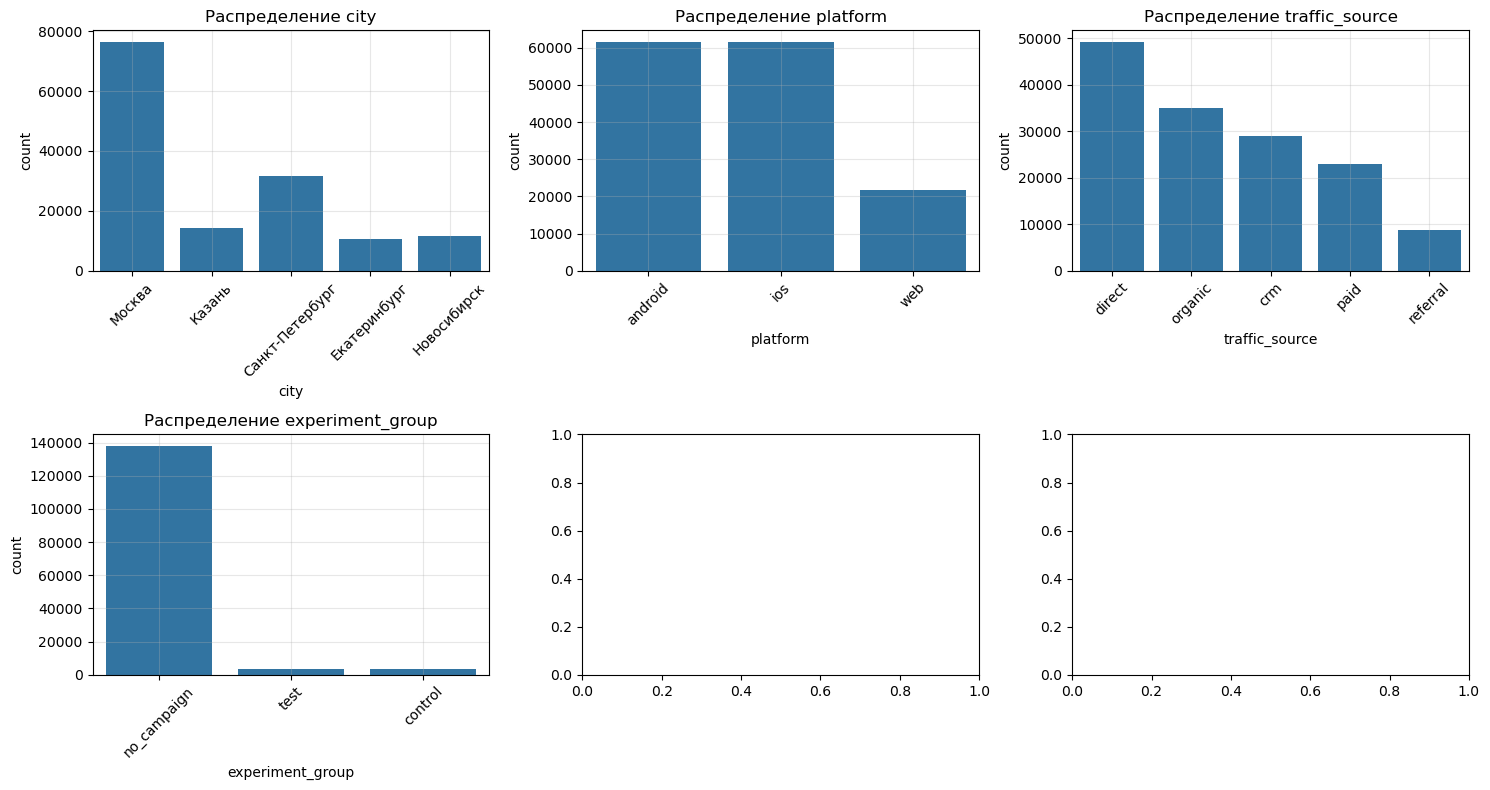

In [216]:
funnel_features = ['city', 'platform', 'traffic_source', 'experiment_group']
plot_features(funnel_df, funnel_features)

##### Построим воронку по этапам

Основные этапы оттока пользователей

1. service_visit -> product_search = 28.05% - пользователи зашли, но не стали ничего искать

2. product_card_view -> add_to_cart = 28.88% - посмотрели товар, но не добавили в корзину

3. cart_visit -> purchase = 9% - зашли в корзину, но не купили товар

In [217]:
def plot_funnel(df: pd.DataFrame, funnel_steps: List[str]) -> None:
    funnel_count = df[funnel_steps].sum()
    funnel_pct = (funnel_count / funnel_count.iloc[0] * 100).round(2)
    plt.figure(figsize=(12, 8))
    bars = plt.bar(x=funnel_count.index, height=funnel_count.values)
    for bar, count, pct in zip(bars, funnel_count, funnel_pct):
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height * 0.7,
            f'{pct:.2f}%\n({count:,})',
            ha='center', va='top',
            fontsize=12
        )
    plt.title('Воронка пути пользователя', fontsize=14)
    plt.xlabel('Этап воронки', fontsize=14)
    plt.ylabel('Количество сессий', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

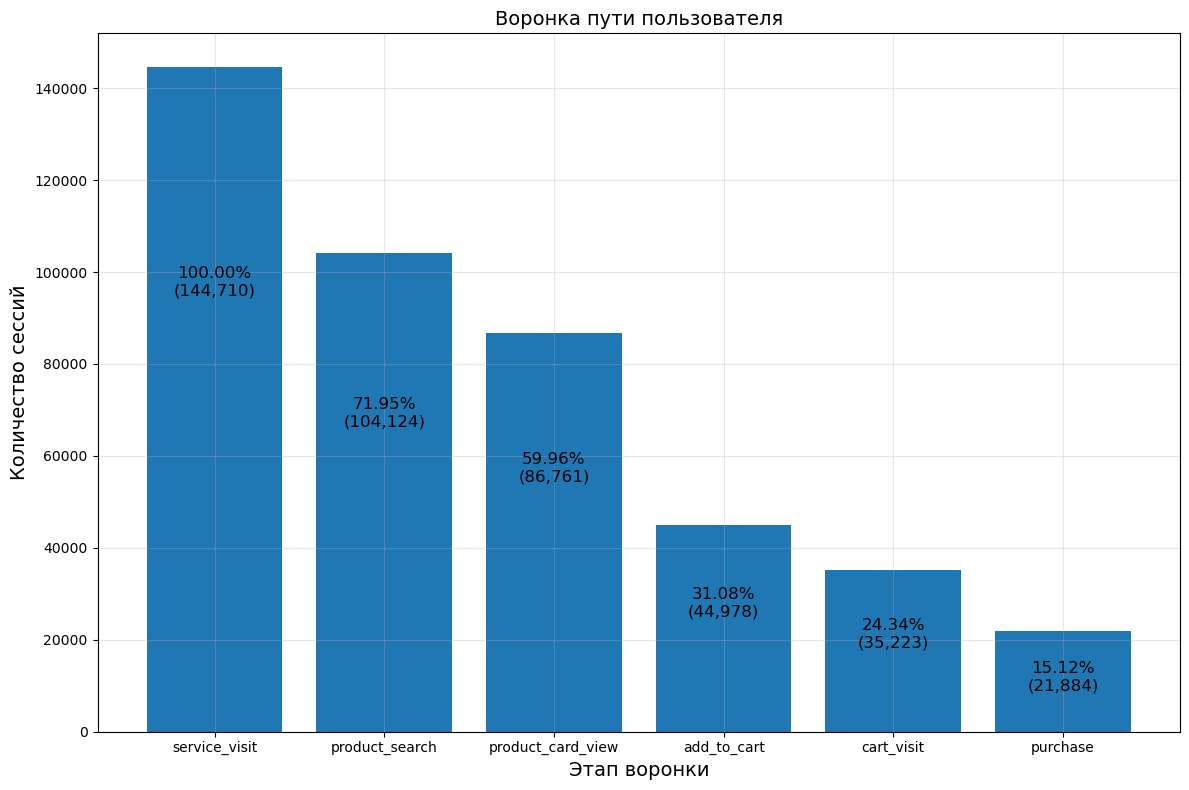

In [218]:
funnel_steps = ['service_visit', 'product_search', 'product_card_view', 'add_to_cart', 'cart_visit', 'purchase']
plot_funnel(funnel_df, funnel_steps)

### Исследование причин падения оборота

##### Дерево метрики GMV
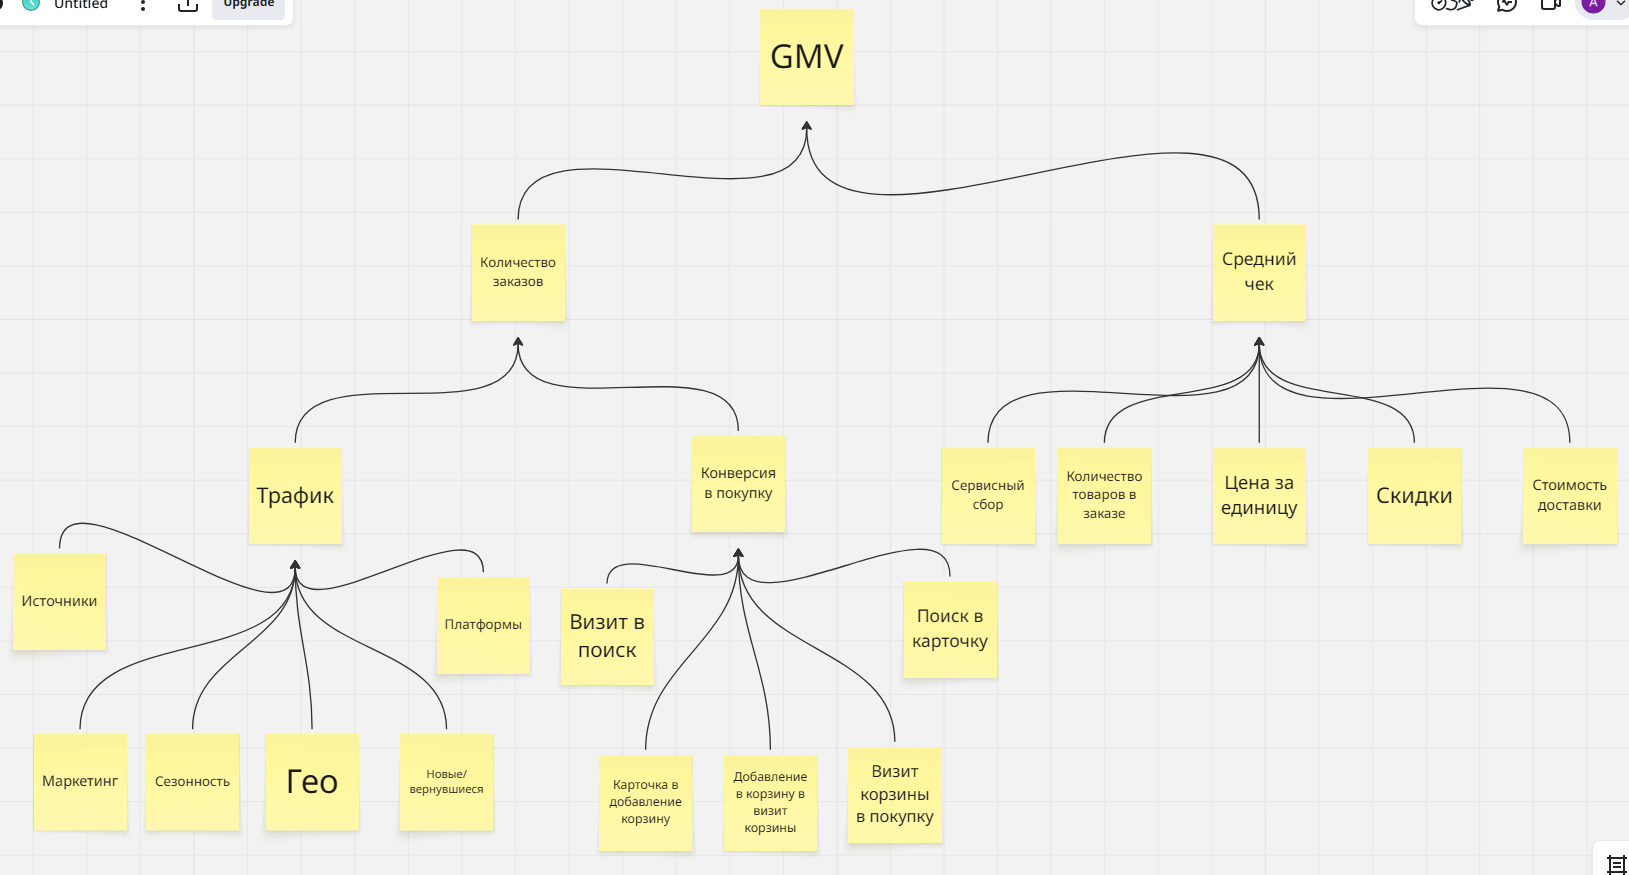

GMV = Трафик * Конверсия * Средний чек

Собираем метрики дерева из датасетов для анализа динамики и воронки

Датафреймы с метриками по месяцам для их визуализации

In [219]:
orders_monthly = orders_df.groupby(orders_df['order_date'].dt.to_period('M')).agg(
    gmv=('gross_merchandise_value', 'sum'),
    paid_amount=('paid_amount', 'sum'),
    order_count=('order_id', 'nunique'),
    avg_check=('paid_amount', 'mean'),
    items_count=('items_count', 'mean'),
    discount_total=('discount_amount', 'sum'),
    delivery_fee_avg=('delivery_fee', 'mean'),
    service_fee_avg=('service_fee', 'mean')
).reset_index()
orders_monthly['discount_rate'] = orders_monthly['discount_total'] / orders_monthly['gmv']
orders_monthly['avg_discount_per_order'] = orders_monthly['discount_total'] / orders_monthly['order_count']
orders_monthly['cost_per_item_gmv'] = orders_monthly['gmv'] / (orders_monthly['order_count'] * orders_monthly['items_count'])
orders_monthly['cost_per_item_discount'] = orders_monthly['paid_amount'] / (orders_monthly['order_count'] * orders_monthly['items_count'])

funnel_monthly = funnel_df.groupby(funnel_df['session_date'].dt.to_period('M')).agg(
    total_sessions=('service_visit', 'sum'),
    product_search=('product_search', 'sum'),
    product_card_view=('product_card_view', 'sum'),
    add_to_cart=('add_to_cart', 'sum'),
    cart_visit=('cart_visit', 'sum'),
    purchase=('purchase', 'sum'),
).reset_index()
funnel_monthly['conversion_search'] = funnel_monthly['product_search'] / funnel_monthly['total_sessions']
funnel_monthly['conversion_card_view'] = funnel_monthly['product_card_view'] / funnel_monthly['product_search']
funnel_monthly['conversion_add'] = funnel_monthly['add_to_cart'] / funnel_monthly['product_card_view']
funnel_monthly['conversion_cart_visit'] = funnel_monthly['cart_visit'] / funnel_monthly['add_to_cart']
funnel_monthly['conversion_purchase'] = funnel_monthly['purchase'] / funnel_monthly['cart_visit']
funnel_monthly['conversion_total'] = funnel_monthly['purchase'] / funnel_monthly['total_sessions']

marketing_monthly = marketing_df.groupby(marketing_df['send_datetime'].dt.to_period('M')).agg(
    communication_count=('communication_type', 'count'),
    sent=('send_status', lambda x: (x == 'sent').sum())
).reset_index()

first_order = orders_df.groupby('client_id')['order_date'].min().reset_index()[['client_id', 'order_date']].rename(columns={'order_date': 'first_order_date'})

orders_cohort = orders_df.merge(first_order, on='client_id', how='left')
orders_cohort['is_new'] = orders_cohort['order_date'] == orders_cohort['first_order_date']

cohort_monthly = orders_cohort.groupby('first_order_date').agg(
    new_orders=('is_new', 'sum'),
    total_orders=('order_id', 'count')
).reset_index().rename(columns={'first_order_date': 'cohort_month'})
cohort_monthly['returning_orders'] = cohort_monthly['total_orders'] - cohort_monthly['new_orders']


Датафреймы с метриками по дням для проверки их статистической значимости

In [220]:
orders_daily = orders_df.groupby(orders_df['order_date'].dt.date).agg(
    gmv=('gross_merchandise_value', 'sum'),
    paid_amount=('paid_amount', 'sum'),
    order_count=('order_id', 'nunique'),
    avg_check=('paid_amount', 'mean'),
    items_count=('items_count', 'mean'),
    discount_total=('discount_amount', 'sum'),
    delivery_fee_avg=('delivery_fee', 'mean'),
    service_fee_avg=('service_fee', 'mean')
).reset_index()
orders_daily['discount_rate'] = orders_daily['discount_total'] / orders_daily['gmv']
orders_daily['avg_discount_per_order'] = orders_daily['discount_total'] / orders_daily['order_count']
orders_daily['cost_per_item_gmv'] = orders_daily['gmv'] / (orders_daily['order_count'] * orders_daily['items_count'])
orders_daily['cost_per_item_discount'] = orders_daily['paid_amount'] / (orders_daily['order_count'] * orders_daily['items_count'])

funnel_daily = funnel_df.groupby(funnel_df['session_date'].dt.date).agg(
    total_sessions=('service_visit', 'sum'),
    product_search=('product_search', 'sum'),
    product_card_view=('product_card_view', 'sum'),
    add_to_cart=('add_to_cart', 'sum'),
    cart_visit=('cart_visit', 'sum'),
    purchase=('purchase', 'sum'),
).reset_index()
funnel_daily['conversion_search'] = funnel_daily['product_search'] / funnel_daily['total_sessions']
funnel_daily['conversion_card_view'] = funnel_daily['product_card_view'] / funnel_daily['product_search']
funnel_daily['conversion_add'] = funnel_daily['add_to_cart'] / funnel_daily['product_card_view']
funnel_daily['conversion_cart_visit'] = funnel_daily['cart_visit'] / funnel_daily['add_to_cart']
funnel_daily['conversion_purchase'] = funnel_daily['purchase'] / funnel_daily['cart_visit']
funnel_daily['conversion_total'] = funnel_daily['purchase'] / funnel_daily['total_sessions']

marketing_daily = marketing_df.groupby(marketing_df['send_datetime'].dt.date).agg(
    communication_count=('communication_type', 'count'),
    sent=('send_status', lambda x: (x == 'sent').sum())
).reset_index()


cohort_daily = orders_cohort.groupby(orders_cohort['order_date'].dt.date).agg(
    new_orders=('is_new', 'sum'),
    total_orders=('order_id', 'count')
).reset_index().rename(columns={'order_date': 'date'})
cohort_daily['returning_orders'] = cohort_daily['total_orders'] - cohort_daily['new_orders']

Объединим все метрики в соответствующие датафреймы для удобства работы с ними

In [221]:
metrics_monthly = (
    orders_monthly.merge(funnel_monthly, left_on='order_date', right_on='session_date', how='left')
    .merge(marketing_monthly, left_on='order_date', right_on='send_datetime', how='left')
    .merge(cohort_monthly, left_on='order_date', right_on='cohort_month', how='left')
)
metrics_monthly['order_date'] = metrics_monthly['order_date'].astype(str)

metrics_daily = (
    orders_daily.merge(funnel_daily, left_on='order_date', right_on='session_date', how='left')
    .merge(marketing_daily, left_on='order_date', right_on='send_datetime', how='left')
    .merge(cohort_daily, left_on='order_date', right_on='date', how='left')
)
metrics_daily['order_date'] = pd.to_datetime(metrics_daily['order_date'])

In [222]:
def plot_metrics(df: pd.DataFrame, metrics_to_plot: Dict[str, str], title: str) -> None:
    df_pct = df.copy()
    for col, label in metrics_to_plot.items():
        df_pct[f'{col}_pct'] = df_pct[col] / df_pct[col].iloc[0] * 100
    plt.figure(figsize=(12, 6))
    for col, label in metrics_to_plot.items():
        sns.lineplot(data=df_pct, x='order_date', y=f'{col}_pct', marker='o', label=label)
    plt.title(title, fontsize=16)
    plt.xlabel('Месяц', fontsize=14)
    plt.ylabel('Изменение метрики (%)', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

significant_metrics = []

def check_significance(df: pd.DataFrame,
                       metrics: Dict[str, str],
                       date_col: str,
                       month_1: str,
                       month_2: str,
                       alpha: float = 0.05
                    ) -> pd.DataFrame:
    global significant_metrics
    results = []
    for col, label in metrics.items():
        m1 = df[df[date_col].dt.to_period('M').astype(str) == month_1]
        m2 = df[df[date_col].dt.to_period('M').astype(str) == month_2]
        data_1 = m1[col]
        data_2 = m2[col]
        _, p_value = stats.ttest_ind(data_1, data_2, equal_var=False)
        sign = p_value < alpha
        if sign and label not in [m['metric'] for m in significant_metrics]:
            significant_metrics.append({
                'metric': label,
                'p_value': round(p_value, 6),
                'significant': sign
            })
        results.append({
            'metric': label,
            'p_value': round(p_value, 6),
            'significant': sign
        })
    return pd.DataFrame(results)


##### Динамика основных метрик по месяцам и проверка на значимость с предыдущем месяцем

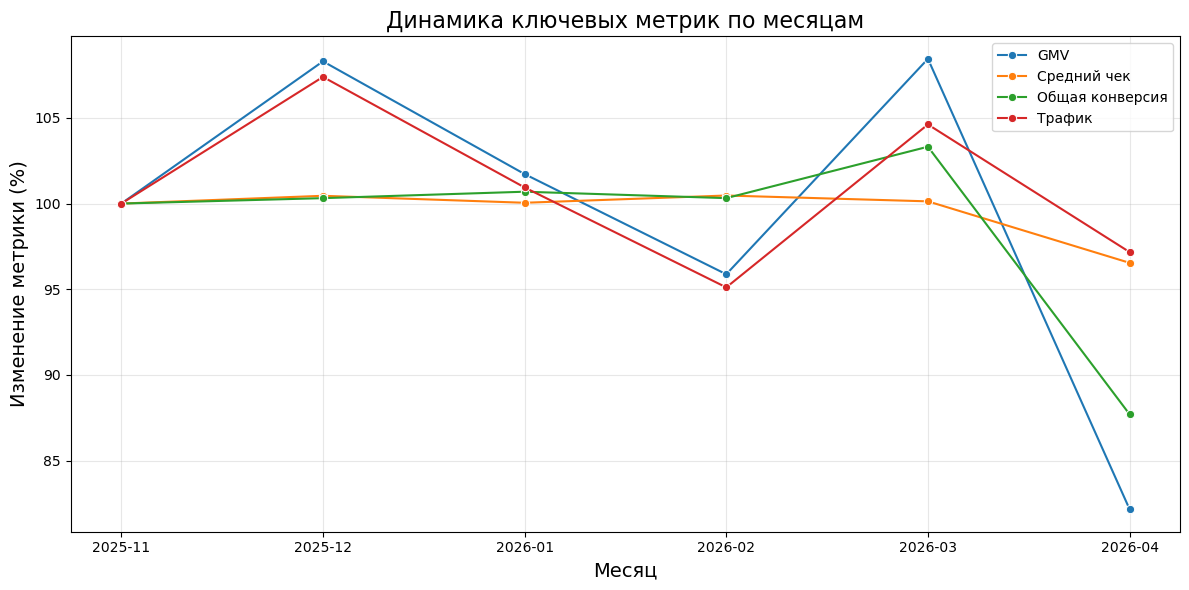

In [223]:
main_metrics = {
    'gmv': 'GMV',
    'avg_check': 'Средний чек',
    'conversion_total': 'Общая конверсия',
    'total_sessions': 'Трафик',
}

plot_metrics(metrics_monthly, main_metrics, 'Динамика ключевых метрик по месяцам')

In [224]:
main_significance = check_significance(
    df=metrics_daily,
    metrics=main_metrics,
    date_col='order_date',
    month_1='2026-03',
    month_2='2026-04',
)
main_significance


,metric,p_value,significant
0,GMV,0.000000,True
1,Средний чек,0.000229,True
2,Общая конверсия,0.000000,True
3,Трафик,0.076061,False


По динамике основных метрик видно, что больше всего на падение GMV влияет средний чек и общая конверсия  - все они статистически значимо ухудшают значение оборота.

##### Динамика GMV и конверсии

Теперь декомпозируем воронку и посмотрим на влияние каждого шага конверсии на GMV

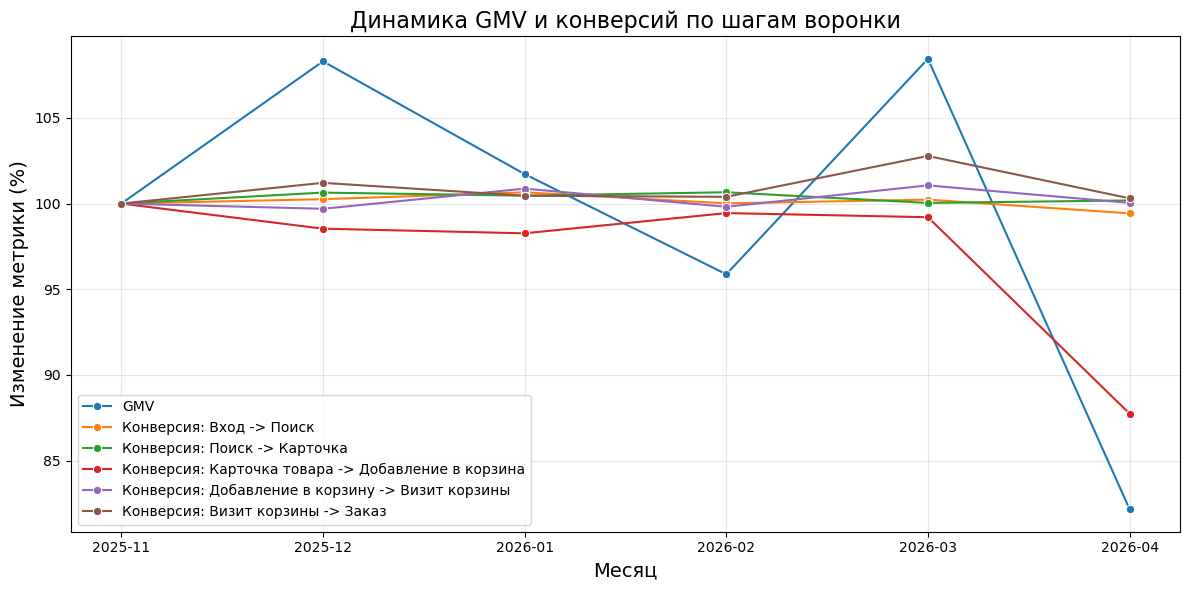

In [225]:
funnel_steps_metrics = {
    'gmv': 'GMV',
    'conversion_search': 'Конверсия: Вход -> Поиск',
    'conversion_card_view': 'Конверсия: Поиск -> Карточка',
    'conversion_add': 'Конверсия: Карточка товара -> Добавление в корзина',
    'conversion_cart_visit': 'Конверсия: Добавление в корзину -> Визит корзины',
    'conversion_purchase': 'Конверсия: Визит корзины -> Заказ'
}

plot_metrics(metrics_monthly, funnel_steps_metrics, 'Динамика GMV и конверсий по шагам воронки')

In [226]:
conversion_significance = check_significance(
    df=metrics_daily,
    metrics=funnel_steps_metrics,
    date_col='order_date',
    month_1='2026-03',
    month_2='2026-04',
)
conversion_significance

,metric,p_value,significant
0,GMV,0.000000,True
1,Конверсия: Вход -> Поиск,0.207820,False
2,Конверсия: Поиск -> Карточка,0.773242,False
3,Конверсия: Карточка товара -> Добавление в кор...,0.000000,True
4,Конверсия: Добавление в корзину -> Визит корзины,0.306982,False
5,Конверсия: Визит корзины -> Заказ,0.184328,False


Клиенты перестали добавлять товары в корзину - конверсия на этом этапе уменьшилась примерно на 13%, такое изменение существенно влияет на падение GMV

##### Динамика среднего чека и его составляющих
Рассмотрим количество товаров в заказе, стоимость единицы товара, скидка на заказ и стоимость доставки - по месяцам

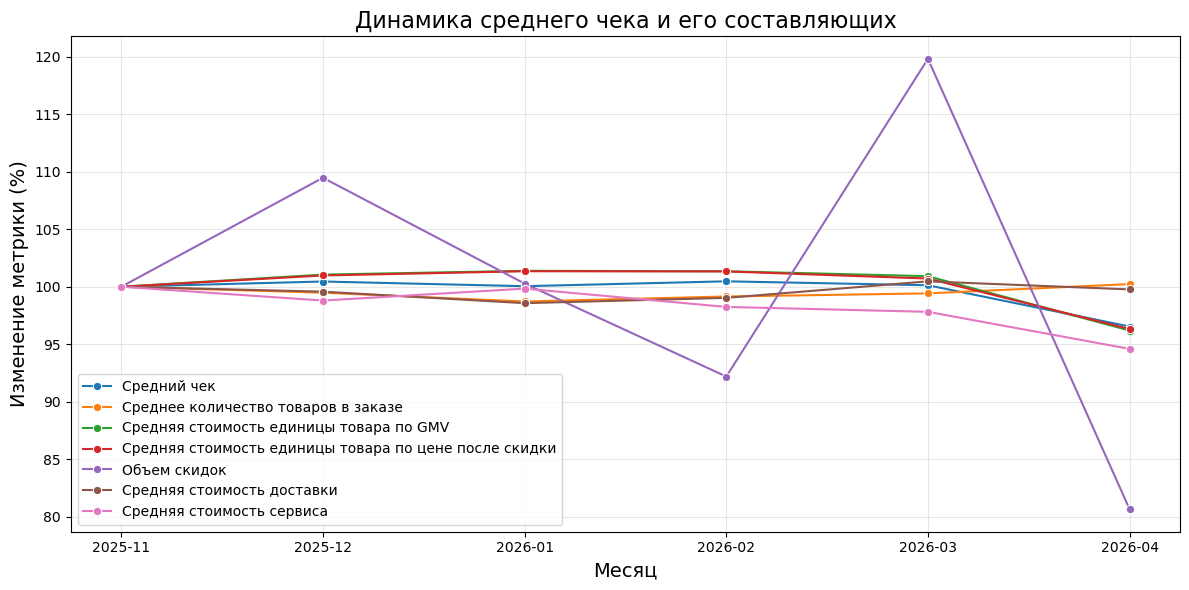

In [227]:
avg_check_metrics = {
    'avg_check': 'Средний чек',
    'items_count': 'Среднее количество товаров в заказе',
    'cost_per_item_gmv': 'Средняя стоимость единицы товара по GMV',
    'cost_per_item_discount': 'Средняя стоимость единицы товара по цене после скидки',
    'discount_total': 'Объем скидок',
    'delivery_fee_avg': 'Средняя стоимость доставки',
    'service_fee_avg': 'Средняя стоимость сервиса'
}

plot_metrics(metrics_monthly, avg_check_metrics, 'Динамика среднего чека и его составляющих')

In [228]:
avg_check_significance = check_significance(
    df=metrics_daily,
    metrics=avg_check_metrics,
    date_col='order_date',
    month_1='2026-03',
    month_2='2026-04',
)
avg_check_significance

,metric,p_value,significant
0,Средний чек,0.000229,True
1,Среднее количество товаров в заказе,0.348848,False
2,Средняя стоимость единицы товара по GMV,0.000149,True
3,Средняя стоимость единицы товара по цене после...,0.000332,True
4,Объем скидок,0.000008,True
5,Средняя стоимость доставки,0.721942,False
6,Средняя стоимость сервиса,0.195138,False


На падение среднего чека очень сильно повлял спад объёма скидок на товары. Кроме того, снизилась стоимость единицы товара в корзине с сохранением количества товара в корзине, что означает, что пользователи стали переходить на более дешевые аналоги товаров

### Финальная гипотеза

Ниже представлены метрики, по которым обнаружены стат значимые изменения в апреле по сравнению с мартом, будем строить гипотезу от них

In [229]:
pd.DataFrame(significant_metrics)

,metric,p_value,significant
0,GMV,0.000000,True
1,Средний чек,0.000229,True
2,Общая конверсия,0.000000,True
3,Конверсия: Карточка товара -> Добавление в кор...,0.000000,True
4,Средняя стоимость единицы товара по GMV,0.000149,True
5,Средняя стоимость единицы товара по цене после...,0.000332,True
6,Объем скидок,0.000008,True


#### На падение GMV повлияло уменьшение скидок на товары в сервисе доставки. Из-за уменьшения их объема упала конверсия из посещения карточки товара в добавление его в корзину. Они заходят на страницу товара, разочаровываются от его цены и переходят к более дешевым аналогам - на это указывает снижение средней цены на товар при сохранении их количества в корзине.

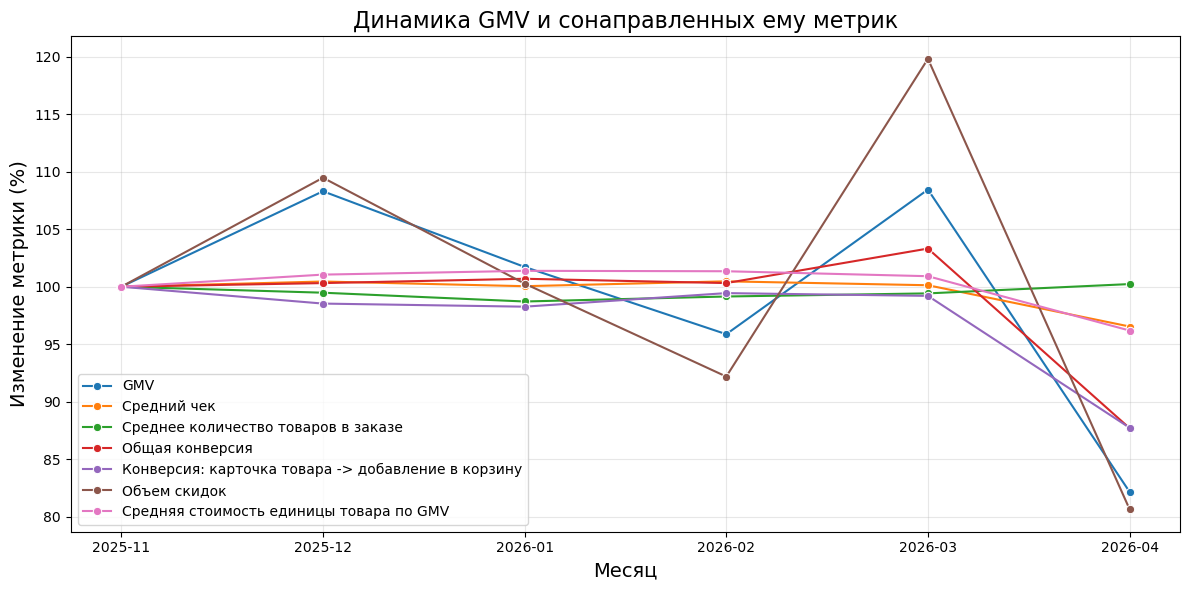

In [230]:
final_metrics = {
    'gmv': 'GMV',
    'avg_check': 'Средний чек',
    'items_count': 'Среднее количество товаров в заказе',
    'conversion_total': 'Общая конверсия',
    'conversion_add': 'Конверсия: карточка товара -> добавление в корзину',
    'discount_total': 'Объем скидок',
    'cost_per_item_gmv': 'Средняя стоимость единицы товара по GMV',
}
plot_metrics(metrics_monthly, final_metrics, 'Динамика GMV и сонаправленных ему метрик')

In [231]:
final_significance = check_significance(
    df=metrics_daily,
    metrics=final_metrics,
    date_col='order_date',
    month_1='2026-03',
    month_2='2026-04',
)
final_significance

,metric,p_value,significant
0,GMV,0.000000,True
1,Средний чек,0.000229,True
2,Среднее количество товаров в заказе,0.348848,False
3,Общая конверсия,0.000000,True
4,Конверсия: карточка товара -> добавление в кор...,0.000000,True
5,Объем скидок,0.000008,True
6,Средняя стоимость единицы товара по GMV,0.000149,True


Для корректности сравнения рассчитаем разницу показателей за март и апрель

In [232]:
date_fall = pd.to_datetime('2026-04-01')
before_fall = metrics_daily[(pd.to_datetime(metrics_daily['order_date']) >= date_fall - pd.DateOffset(months=1))&(pd.to_datetime(metrics_daily['order_date']) < date_fall)]
after_fall = metrics_daily[pd.to_datetime(metrics_daily['order_date']) >= date_fall]

metric_summary = {}
final_metrics_summary = {
    'gmv': 'GMV',
    'avg_check': 'Средний чек',
    'items_count': 'Среднее количество товаров в заказе',
    'conversion_total': 'Общая конверсия',
    'conversion_add': 'Конверсия: карточка товара -> добавление в корзину',
    'discount_total': 'Объем скидок',
    'cost_per_item_gmv': 'Средняя стоимость единицы товара по GMV',
}

for col, label in final_metrics.items():
    if col in ['conversion_total', 'conversion_add', 'cost_per_item_gmv', 'avg_check', 'items_count']:
        metric_summary[label] = {
            'Месяц до падения': before_fall[col].mean(),
            'После падения': after_fall[col].mean(),
            'Разница': after_fall[col].mean() - before_fall[col].mean(),
            'Разница (%)': (after_fall[col].mean() - before_fall[col].mean()) / before_fall[col].mean() * 100
        }
    else:
        metric_summary[label] = {
            'Месяц до падения': before_fall[col].sum(),
            'После падения': after_fall[col].sum(),
            'Разница': after_fall[col].sum() - before_fall[col].sum(),
            'Разница (%)': (after_fall[col].sum() - before_fall[col].sum()) / before_fall[col].sum() * 100
        }

In [233]:
pd.DataFrame(metric_summary)

,GMV,Средний чек,Среднее количество товаров в заказе,Общая конверсия,Конверсия: карточка товара -> добавление в корзину,Объем скидок,Средняя стоимость единицы товара по GMV
Месяц до падения,1.122869e+07,2924.294695,9.754101,0.157969,0.529462,214139.18000,291.067487
После падения,8.506511e+06,2820.992442,9.829043,0.134306,0.468070,144139.46000,277.759448
Разница,-2.722183e+06,-103.302253,0.074942,-0.023662,-0.061392,-69999.72000,-13.308040
Разница (%),-2.424309e+01,-3.532553,0.768315,-14.979102,-11.595096,-32.68889,-4.572149


Итак, сервис уменьшил объем скидок на 32,69% (70000 рублей), в связи с чем потерял 24% оборота (2 722 183 рубля). Кроме того, общая конверсия упала на 14,9%, конверсия карточка -> добавление в корзину на 11,6%. Клиенты стали покупать более дешевые аналоги товаров - сохранили объем продуктовой корзины, но уменьшили среднюю стоимость на 4,57%.

#### Динамика новых и возвращающихся заказов

Трафик статистически не значим, но тем не менее стоит посмотреть, насколько сильно упал прирост новых и возвращающихся заказов

In [234]:
def forecast(df: pd.DataFrame, date_col: str, target: str, cut_date: str) -> None:
    df = df.sort_values(date_col).copy()
    df['X'] = (df[date_col] - df[date_col].min()).dt.days
    train = df[df[date_col] < cut_date]
    X_train = sm.add_constant(train[['X']])
    y_train = train[target]
    model = sm.OLS(y_train, X_train).fit(cov_type='HAC', cov_kwds={'maxlags': 7})
    X_all = sm.add_constant(df[['X']])
    pred_summary = model.get_prediction(X_all).summary_frame(alpha=0.05)
    df['forecast'] = pred_summary['mean']
    df['lower_ci'] = pred_summary['mean_ci_lower']
    df['upper_ci'] = pred_summary['mean_ci_upper']
    
    plt.figure(figsize=(12, 6))
    plt.plot(df[date_col], df[target], marker='o', label='Фактические значения', linewidth=2)
    plt.plot(df[date_col], df['forecast'], '--', label='Прогнозные значения', linewidth=2)
    plt.fill_between(df[date_col], df['lower_ci'], df['upper_ci'], color='orange', alpha=0.2, label='95% доверительный интервал')
    plt.axvline(pd.to_datetime(cut_date), color='red', linestyle=':', label='Дата падения')
    plt.title(f'Прогноз {target}', fontsize=14)
    plt.xlabel('Дата', fontsize=12)
    plt.ylabel(target, fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

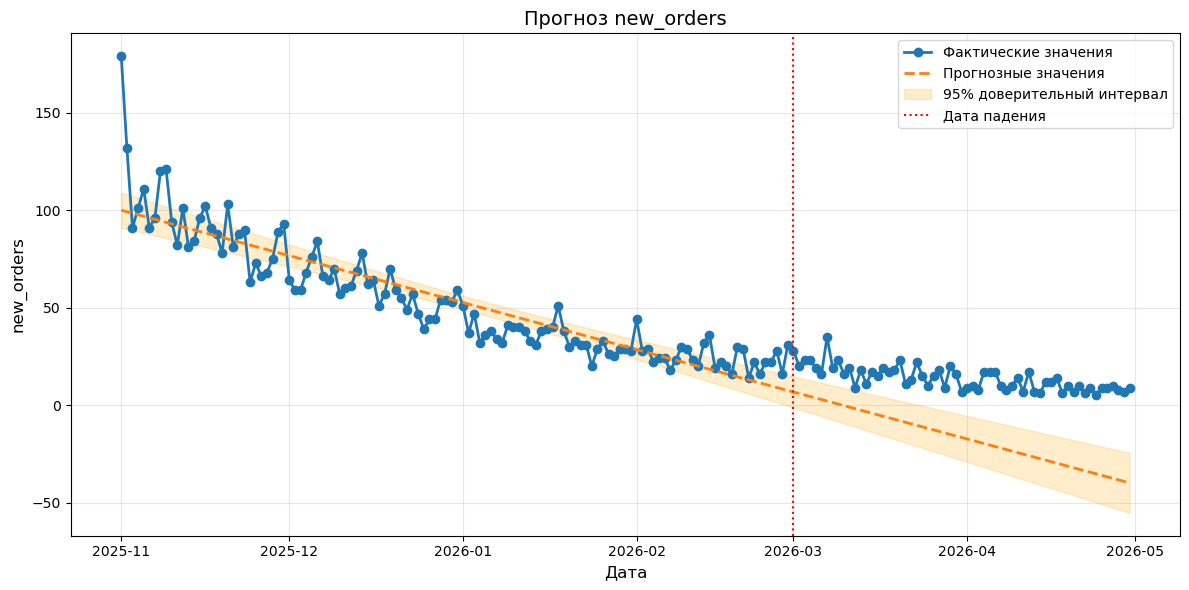

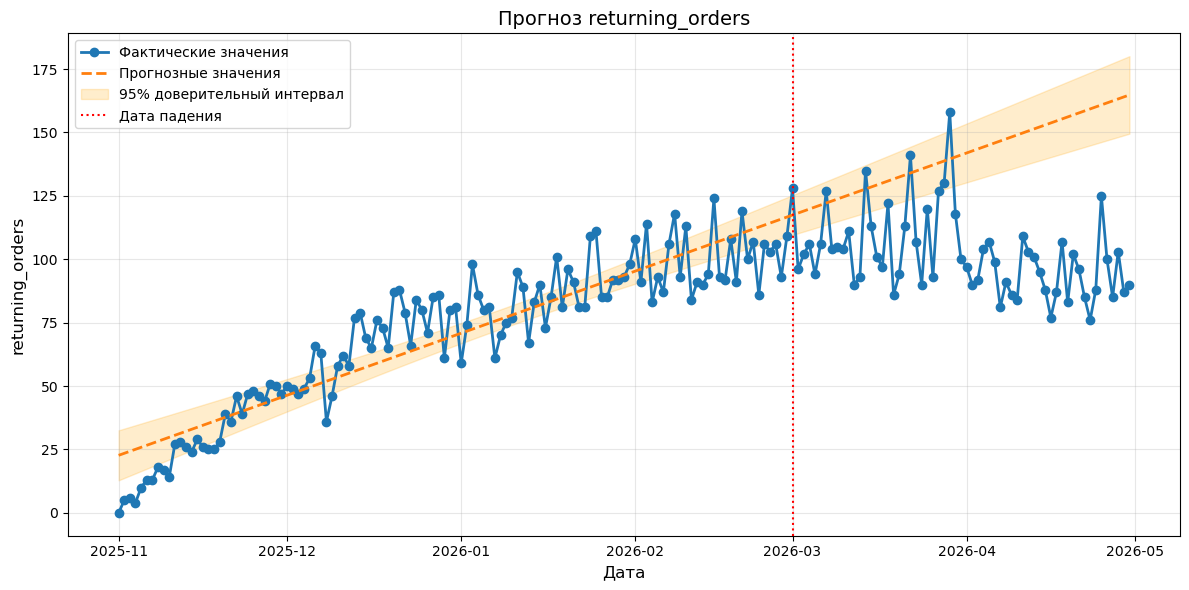

In [235]:

forecast(metrics_daily, 'order_date', 'new_orders', '2026-03-01')
forecast(metrics_daily, 'order_date', 'returning_orders', '2026-03-01')

И новые, и повторные заказы очень сильно отходят от прогнозных значений. Новые заказы достигли точки очень плавного снижения к марту, что может быть характерно для конца насыщения нашего сервиса новыми пользователями - сначала был бурный рост, теперь пришли к плато. Повторные заказы же показывают, что и для них март-апрель стал моментом начала спада - старые пользователи потихоньку уходят из сервиса из-за отмены скидок

##### Рекомендации по итогам анализа:
1. Вернуть прежний объем скидок на товары, ведь они являлись очень важной частью GMV. Можно сфокусироваться на их персонализации по группам товаров, популярных позициях.

2. Клиенты понемногу отваливаются - нужно удерживать старых и активнее привлекать новых. Запускаем офферы на реактивацию клиента, создаем дополнительную подписку с бесплатной доставкой и эксклюзивными предложениями, вводим реферальную программу по приглашению друзей в сервис за скидку. Для новых пользователей предлагаем приветственный бонус на первый заказ в течение недели после регистрации.

3. Для подъема конверсии из карточки товара в добавление в корзину и удержания добавляем "Вас так же может заинтересовать" - товаров на основе самых просматриваемых клиентом категорий, вводим отзывы на продукты из доставки, сравнение цен между магазинами на товар.